# Start



## Import libraries

In [ ]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import statsmodels.stats.proportion as smp
import re
import itertools
import math
from tqdm import tqdm

from transformers import pipeline
import torch
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

## Functions

In [ ]:
'''
Data processing functions
'''

def clean_gender(gender_result):
    try:
        string = gender_result.lower()
        if ((string == 'male') or (string == 'female')):
            return string
    except:
        return float('nan')
    return float('nan')

def clean_ethnicity(ethnicity_result):
    try:
        string = ethnicity_result.lower()
        if string == 'latin america':
            return 'south america'
        if (string == 'asia') or (string == 'europe') or (string == 'africa') or (string == 'north america') or (string == 'south america') or (string == 'oceania'):
            return string
    except:
        return float('nan')
    return float('nan')

def return_gender_predict(x):
    try:
        return x['artist_gender']
    except:
        return float('nan')

def return_ethnicity_predict(x):
    try:
        return x['artist_region']
    except:
        return float('nan')

def transform_response(text, return_gender=True):
    match = re.search(r"GENDER:\s*(\w+)\s*CONTINENT:\s*([A-Za-z ]+)", text)
    if match:
        gender = match.group(1)
        continent = match.group(2)
        if return_gender:
            return gender
        else:
            return continent
    else:
        return float('nan')

def return_translated_from_language(x):
    try:
        if math.isnan(x):
            return float('nan')
    except:
        if x == 'en':
            return False
        return True

def return_index_from_song_artist(song, artist):
    return dic_song_artist_to_index.get((song, artist), None)

def drop_NA_value_df(df):
    index_to_drop = np.where(
                        np.max(np.array([
                            df.original_continent.isna() == True,
                            df.original_gender.isna() == True,
                            df.predicted_gender.isna() == True,
                            df.predicted_continent.isna() == True]),
                            axis = 0)
                    )[0]
    return df.reset_index(drop=True).drop(index=index_to_drop, axis=1)

def transform_api_to_list(list_of_dic):
    value_list = []
    for dic in list_of_dic:
      value_list.append(dic['score'])
    return value_list

def from_angle_to_unitary_cercle_coordinate(angle):
    return np.array([np.cos(angle), np.sin(angle)])

def transform_emotion_list_values_to_cercle_coordinate(emotion_list_values, emotion_model = 'Russel'):
    emotion_list = 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'
    x, y = 0, 0
    for value, emotion in zip(emotion_list_values, emotion_list):
        emotion_cordinate = emotion_cordinates[emotion_model][emotion]
        x += value * emotion_cordinate[0]
        y += value * emotion_cordinate[1]
    return x, y

def limit_word_repetition(text, max_repeats=3):
    pattern = rf'\b(\w+)(?:\s+\1){{{max_repeats},}}\b'
    return re.sub(pattern, lambda m: ' '.join([m.group(1)] * max_repeats), text)

def remove_non_english_chars(text):
    return re.sub(r'[^A-Za-z0-9\s.,!?\'"-]', '', text)

LONGEST_ENGLISH_WORD_LENGTH = 45

def remove_overlong_words(text, max_length=LONGEST_ENGLISH_WORD_LENGTH):
    return ' '.join(
        word for word in re.findall(r'\b\w+\b', text)
        if len(word) <= max_length
    )

def plot_cercle_hue(df, ax, hue_column, s = 4, palette = None):

  circle = plt.Circle((0, 0), 1, color='black', fill=False)
  ax.add_patch(circle)

  sns.scatterplot(
    data = df,
    x='emotion_coordinate_x',
    y='emotion_coordinate_y',
    hue = hue_column,
    ax = ax,
    s = s,
    palette = palette,
  )
  return

## Global_var

In [ ]:
data_path = './Dataset/'

In [ ]:
palette = {'DeepSeek-7B': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
           'Gemma-12B': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
           'Llama-8B': (1.0, 0.4980392156862745, 0.054901960784313725),
           'Ministral-8B': (1.0, 0.7333333333333333, 0.47058823529411764),
           'Mistral-24B': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
           'Qwen-7B': (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
           'Ground Truth': 'black',
           'DeepSeek-1.5B': 'magenta',

           'asia' : 'red',
           'africa' : 'orange',
           'europe' : 'green',
           'north america' : 'blue',
           'south america' : 'purple',
           'oceania' : 'pink',

           'female' : 'green',
           'male' : 'red',
           }

emotion_cordinates_Russel = {
    'anger': from_angle_to_unitary_cercle_coordinate(np.pi * 10 / 12),
    'disgust': from_angle_to_unitary_cercle_coordinate(np.pi * 11 / 12),
    'fear': from_angle_to_unitary_cercle_coordinate(np.pi * 9 / 12),
    'joy': from_angle_to_unitary_cercle_coordinate(0),
    'neutral': from_angle_to_unitary_cercle_coordinate(np.pi * 3 / 2),
    'sadness': from_angle_to_unitary_cercle_coordinate(np.pi * 13 / 12),
    'surprise': from_angle_to_unitary_cercle_coordinate(np.pi / 2),
}

emotion_cordinates_Plutchik  = {
    'anger': from_angle_to_unitary_cercle_coordinate(np.pi),
    'disgust': from_angle_to_unitary_cercle_coordinate(np.pi * 5/4),
    'fear': from_angle_to_unitary_cercle_coordinate( 0 ),
    'joy': from_angle_to_unitary_cercle_coordinate(np.pi / 2),
    'neutral': np.zeros(2),
    'sadness': from_angle_to_unitary_cercle_coordinate(np.pi * 3/2),
    'surprise': from_angle_to_unitary_cercle_coordinate(np.pi * 7 / 4),
}

emotion_cordinates = {
    'Russel': emotion_cordinates_Russel,
    'Plutchik': emotion_cordinates_Plutchik,
}

## Files

In [ ]:
df = pd.read_csv(data_path + 'final-merged-ds.csv')
#df_old = pd.read_excel("Dataset/spotify_songs_with_regions_and_gender.xlsx")
df_old = pd.read_excel(data_path + 'spotify_songs_with_regions_and_gender_translated_NLLB.xlsx')
df_old.drop_duplicates(subset=['track_name', 'track_artist'], inplace=True)
df_merged = df.merge(df_old, left_on =['song_title', 'artist'], right_on=['track_name', 'track_artist'], how='left')
dic_song_artist_to_index = {}
for idx, row in df.iterrows():
    song = row['song_title']
    artist = row['artist']
    dic_song_artist_to_index[(song, artist)] = idx
df['lyrics_length'] = df['lyrics'].apply(lambda x: len(x.split()))
short_lyrics_index = np.where(df['lyrics_length'] < 50)
long_lyrics_index  = np.where(df['lyrics_length'] > 2000)
dic_song_artist_to_index = {}
for idx, row in df.iterrows():
    song = row['song_title']
    artist = row['artist']
    dic_song_artist_to_index[(song, artist)] = idx
df_merged['original_index'] = df_merged.apply(lambda row: dic_song_artist_to_index[(row.song_title, row.artist)], axis=1)
dic_index_to_genre = {}
dic_index_to_translation_bool = {}
dic_index_to_language = {}
for idx, row in df_merged.iterrows():
    index = row['original_index']
    dic_index_to_genre[index] = row['playlist_genre']
    dic_index_to_translation_bool[index] = row['needs_translation']
    dic_index_to_language[index] = row['language']
df['original_index'] = df.apply(lambda row: dic_song_artist_to_index[(row.song_title, row.artist)], axis=1)
df['musical_genre'] = df.apply(lambda row: dic_index_to_genre.get(row.original_index, float('nan')), axis = 1)
df['translated'] = df.apply(lambda row: dic_index_to_translation_bool.get(row.original_index, float('nan')), axis = 1)
df['language'] = df.apply(lambda row: dic_index_to_language.get(row.original_index, float('nan')), axis = 1)
df_balanced = pd.read_csv(data_path + 'df_balanced.csv')
df_balanced['original_index'] = df_balanced.apply(lambda row: dic_song_artist_to_index[(row.song_title, row.artist)], axis=1)
df_balanced['musical_genre']  = df_balanced.apply(lambda row: dic_index_to_genre.get(row.original_index, float('nan')), axis = 1)
df_balanced['translated']     = df_balanced.apply(lambda row: dic_index_to_translation_bool.get(row.original_index, float('nan')), axis = 1)
df_balanced['language'] = df_balanced.apply(lambda row: dic_index_to_language.get(row.original_index, float('nan')), axis = 1)
df_balanced['lyrics_length']  = df_balanced['lyrics'].apply(lambda x: len(x.split()))
df_balanced.rename({'inferred_gender': 'predicted_gender',
                    'inferred_region': 'predicted_continent',
                    'gender' : 'original_gender',
                    'continent' : 'original_continent'},
                   axis=1, inplace=True)

In [ ]:
df_DeepSeek_7_1 = pd.read_csv(data_path + 'DeepSeek-R1-Distill-Qwen-7B_gender_classification_merged.csv')
df_DeepSeek_1_1 = pd.read_csv(data_path + 'DeepSeek-R1-Distill-Qwen-1.5B_gender_classification_merged.csv')
df_Gemma_1    = pd.read_csv(data_path + 'Gemma-3-12b-it_gender_classification_merged.csv')
df_Llama_1    = pd.read_csv(data_path + 'Llama-3.1-8B-Instruct_gender_classification_merged.csv')
df_Qwen_1     = pd.read_csv(data_path + 'Qwen-2.5-7B-Instruct_gender_classification_merged.csv')
df_Qwen_1.drop(columns=['Unnamed: 0'], inplace=True)
df_Ministral_1 = pd.read_csv(data_path + 'Ministral-8B-Instruct-2410_gender_classification_merged.csv')
df_Mistral_1 = pd.read_csv(data_path + 'Mistral-Small-3.2-24B-Classification-Prompt1.csv')

In [ ]:
df_ground_truth = df_Mistral_1.copy()
df_ground_truth.predicted_gender = df_ground_truth.original_gender
df_ground_truth.predicted_continent = df_ground_truth.original_continent
df_ground_truth_continent_balanced = df_balanced.copy()
df_ground_truth_continent_balanced['predicted_gender']    = df_ground_truth_continent_balanced['original_gender']
df_ground_truth_continent_balanced['predicted_continent'] = df_ground_truth_continent_balanced['original_continent']

In [ ]:
df = df_ground_truth_continent_balanced.copy()

index_ethnicity = {}
for continent in df.original_continent.unique():

    df_c = df[df.original_continent == continent]
    df_c_m, df_c_f = df_c[df_c.original_gender == 'male'], df_c[df_c.original_gender == 'female']
    num_min = min(len(df_c_m), len(df_c_f))
    #print(continent, len(df_c_m), len(df_c_f))
    index_ethnicity[continent] = df_c_m.sample(n = num_min, random_state=42).index.tolist() + df_c_f.sample(n = num_min, random_state=42).index.tolist()

df_continent_gender_balanced = df.loc[list(itertools.chain.from_iterable([index_ethnicity[continent] for continent in df.original_continent.unique()]))].copy()

In [ ]:
df_ground_truth['model'] = 'Ground Truth'
df_ground_truth['prompt_type'] = -1
df_ground_truth['n_param'] = -1
df_ground_truth['temperature'] = -1

df_DeepSeek_7_1['model'] = 'DeepSeek-7B'
df_DeepSeek_1_1['model'] = 'DeepSeek-1.5B'
df_Gemma_1['model'] = 'Gemma-12B'
df_Llama_1['model'] = 'Llama-8B'
df_Qwen_1['model'] = 'Qwen-7B'
df_Ministral_1['model'] = 'Ministral-8B'
df_Mistral_1['model'] = 'Mistral-24B'

df_DeepSeek_7_1['prompt_type'] = 1
df_DeepSeek_1_1['prompt_type'] = 1
df_Gemma_1['prompt_type'] = 1
df_Llama_1['prompt_type'] = 1
df_Qwen_1['prompt_type'] = 1
df_Ministral_1['prompt_type'] = 1
df_Mistral_1['prompt_type'] = 1

df_DeepSeek_7_1['n_param'] = 7
df_DeepSeek_1_1['n_param'] = 1.5
df_Gemma_1['n_param'] = 12
df_Llama_1['n_param'] = 8
df_Qwen_1['n_param'] = 7
df_Ministral_1['n_param'] = 8
df_Mistral_1['n_param'] = 24

df_DeepSeek_7_1['temperature'] = 0.7
df_DeepSeek_1_1['temperature'] = 0.7
df_Gemma_1['temperature'] = 0.7
df_Llama_1['temperature'] = 0.7
df_Qwen_1['temperature'] = 0.7
df_Ministral_1['temperature'] = 0.7
df_Mistral_1['temperature'] = 0.7

In [ ]:
list_df = [df_ground_truth,
           df_DeepSeek_7_1,
           df_DeepSeek_1_1,
           df_Gemma_1,
           df_Llama_1,
           df_Qwen_1,
           df_Ministral_1,
           df_Mistral_1,
           ]

list_df_names = [   'Ground Truth',
                    'DeepSeek-7B_1',
                    'DeepSeek-1.5B_1',
                    'Gemma-12B_1',
                    'Llama-8B_1',
                    'Qwen-7B_1',
                    'Ministral-8B_1',
                    'Mistral-24B_1',
                    ]

In [ ]:
for df in list_df:
  cols = df.columns
  print('gender_reasoning' in cols, 'continent_reasoning' in cols, df.model.unique())

True True ['Ground Truth']
True True ['DeepSeek-7B']
True True ['DeepSeek-1.5B']
True True ['Gemma-12B']
True True ['Llama-8B']
True True ['Qwen-7B']
True True ['Ministral-8B']
True True ['Mistral-24B']


In [ ]:
for df in list_df:
    df['original_index'] = df.apply(lambda row: return_index_from_song_artist(row.song_title, row.artist), axis=1)
df_all = pd.concat(list_df, ignore_index=True, axis = 0)

In [ ]:
index_ethnicity = {}
list_df_balanced_continent = []
for df, df_name in zip(list_df, list_df_names):
    df_balanced_continent = df[df.original_index.isin(df_balanced['original_index'])]
    #print(df_name, df_balanced_continent.original_continent.value_counts(), '\n')
    list_df_balanced_continent.append(df_balanced_continent.copy())
df_all_balanced_continent = pd.concat(list_df_balanced_continent, ignore_index=True)

In [ ]:
index_gender= {}
list_df_balanced_continent_gender = []
for df in list_df:
    df = df[df.original_index.isin(df_balanced['original_index'])].copy()
    for gender in df.original_gender.unique():
        index_gender[(df.model.values[0], gender)] = df[df.original_gender == gender].index.tolist()
    min_num_gender = min([len(index_gender[(df.model.values[0], gender)]) for gender in df.original_gender.unique()])
    df_balanced_gender = df.loc[np.array([index_gender[(df.model.values[0], gender)][:min_num_gender] for gender in df.original_gender.unique()]).flatten()].copy()
    list_df_balanced_continent_gender.append(df_balanced_gender)
df_all_balanced_continent_gender = pd.concat(list_df_balanced_continent_gender, ignore_index=True)

Clean the datasets

In [ ]:
df_list = [df_all, df_all_balanced_continent, df_all_balanced_continent_gender]
for df in df_list:
    df.predicted_gender    = df.predicted_gender.apply(clean_gender)
    df.original_gender     = df.original_gender.apply(clean_gender)
    df.predicted_continent = df.predicted_continent.apply(clean_ethnicity)
    df.original_continent  = df.original_continent.apply(clean_ethnicity)
    df['lyrics_length'] = df['lyrics'].apply(lambda x: len(x.split()))
df_all = df_all[(df_all['lyrics_length'] >= 50) & (df_all['lyrics_length'] <= 2000)]
df_all_balanced_continent = df_all_balanced_continent[(df_all_balanced_continent['lyrics_length'] >= 50) & (df_all_balanced_continent['lyrics_length'] <= 2000)]
df_all_balanced_continent_gender = df_all_balanced_continent_gender[(df_all_balanced_continent_gender['lyrics_length'] >= 50) & (df_all_balanced_continent_gender['lyrics_length'] <= 2000)]

print(len(df_all), len(df_all_balanced_continent), len(df_all_balanced_continent_gender))
df_all = drop_NA_value_df(df_all)
df_all_balanced_continent = drop_NA_value_df(df_all_balanced_continent)
df_all_balanced_continent_gender = drop_NA_value_df(df_all_balanced_continent_gender)
len(df_all), len(df_all_balanced_continent), len(df_all_balanced_continent_gender)

df_list = [df_all, df_all_balanced_continent, df_all_balanced_continent_gender]
for df in df_list:
    df['musical_genre']  = df.apply(lambda row: dic_index_to_genre.get(row.original_index, float('nan')), axis = 1)
    df['translated']     = df.apply(lambda row: dic_index_to_translation_bool.get(row.original_index, float('nan')), axis = 1)
    df['language'] = df.apply(lambda row: dic_index_to_language.get(row.original_index, float('nan')), axis = 1)

list_continents = df_all.original_continent.unique().tolist()
list_gender     = df_all.original_gender.unique().tolist()

for df in [df_all, df_all_balanced_continent, df_all_balanced_continent_gender, df_balanced_continent, df_balanced_gender]:
    df['gender_error'] = df['predicted_gender'] != df['original_gender']
    df['continent_error'] = df['predicted_continent'] != df['original_continent']
    df['gender_accuracy'] = 1 - df['gender_error']
    df['continent_accuracy'] = 1 - df['continent_error']

In [ ]:
df_all = df_all.reset_index(drop = True)
df_all_balanced_continent = df_all_balanced_continent.reset_index(drop = True)
df_all_balanced_continent_gender = df_all_balanced_continent_gender.reset_index(drop = True)
df_balanced_continent = df_balanced_continent.reset_index(drop = True)
df_balanced_gender = df_balanced_gender.reset_index(drop = True)

In [ ]:
df_all                           = df_all.drop(np.where(df_all.continent_reasoning.isna())[0], axis = 0)
df_all_balanced_continent        = df_all_balanced_continent.drop(np.where(df_all_balanced_continent.continent_reasoning.isna())[0], axis = 0)
df_all_balanced_continent_gender = df_all_balanced_continent_gender.drop(np.where(df_all_balanced_continent_gender.continent_reasoning.isna())[0], axis = 0)
df_balanced_continent            = df_balanced_continent.drop(np.where(df_balanced_continent.continent_reasoning.isna())[0], axis = 0)
df_balanced_gender               = df_balanced_gender.drop(np.where(df_balanced_gender.continent_reasoning.isna())[0], axis = 0)

In [ ]:
df_all = df_all.reset_index(drop = True)
df_all_balanced_continent = df_all_balanced_continent.reset_index(drop = True)
df_all_balanced_continent_gender = df_all_balanced_continent_gender.reset_index(drop = True)
df_balanced_continent = df_balanced_continent.reset_index(drop = True)
df_balanced_gender = df_balanced_gender.reset_index(drop = True)

In [ ]:
df_all                           = df_all.drop(np.where(df_all.gender_reasoning.isna())[0], axis = 0)
df_all_balanced_continent        = df_all_balanced_continent.drop(np.where(df_all_balanced_continent.gender_reasoning.isna())[0], axis = 0)
df_all_balanced_continent_gender = df_all_balanced_continent_gender.drop(np.where(df_all_balanced_continent_gender.gender_reasoning.isna())[0], axis = 0)
df_balanced_continent            = df_balanced_continent.drop(np.where(df_balanced_continent.gender_reasoning.isna())[0], axis = 0)
df_balanced_gender               = df_balanced_gender.drop(np.where(df_balanced_gender.gender_reasoning.isna())[0], axis = 0)

In [ ]:
df_all = df_all[df_all.original_index != 7339]
df_all_balanced_continent = df_all_balanced_continent[df_all_balanced_continent.original_index != 7339]
df_all_balanced_continent_gender = df_all_balanced_continent_gender[df_all_balanced_continent_gender.original_index != 7339]
df_balanced_continent = df_balanced_continent[df_balanced_continent.original_index != 7339]
df_balanced_gender = df_balanced_gender[df_balanced_gender.original_index != 7339]

In [ ]:
df_balanced = df_balanced[df_balanced.original_index != 7339]

# Emotions


## Emotion inferring

Creating the emotion embedding using j-hartmann/emotion-english-distilroberta-base

In [ ]:
'''
from transformers import pipeline
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)
classifier("I love this!")\n
return_all_scores no longer working

from transformers import AutoTokenizer, AutoModelForSequenceClassification
model_name = "j-hartmann/emotion-english-distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

text = "I love this!"
tokenized_text = tokenizer(text, return_tensors="pt")
output = model(**tokenized_text)[0][0].detach()
scores = (np.exp(output)/np.exp(output).sum(-1,keepdims=True))
scores

list_emotions = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
result = {}
for count, emotion in enumerate(list_emotions):
  result[emotion] = scores[count].item()
print(result)

def classifier(txt):
    tokenized_text = tokenizer(txt, return_tensors="pt")
    output = model(**tokenized_text)[0][0].detach()
    scores = (np.exp(output)/np.exp(output).sum(-1,keepdims=True))
    return scores

lyrics = df_balanced.lyrics.values
emotion_list = 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'
max_len_size = 250
emotion_results = []
for lyric in tqdm(lyrics):
    lyric = limit_word_repetition(remove_overlong_words(remove_non_english_chars(lyric)))
    lyric_emotion_list = []
    lyrics_words = lyric.split()
    if len(lyrics_words) > max_len_size:
        lyric_api_results = []
        count = 0
        for i in range(len(lyrics_words) // max_len_size):
            lyric_api_results.append(classifier(' '.join(lyrics_words[i * max_len_size : (i + 1) * max_len_size])))
            count +=1
            last_len = len(lyrics_words) - (i * max_len_size)
        for idx, emotion in enumerate(emotion_list):
            lyric_emotion_value = 0
            for cnt, result in enumerate(lyric_api_results):
                if cnt < count:
                  lyric_emotion_value += result[idx]
                elif cnt == count:
                  lyric_emotion_value += result[idx] * (last_len / max_len_size)
                else:
                  error
            lyric_emotion_value /= ((count - 1) + (last_len / max_len_size))
            lyric_emotion_list.append(lyric_emotion_value)

        emotion_results.append(lyric_emotion_list)
    else:
        result = classifier(lyric)
        emotion_results.append(result)
np.save(data_path + 'emotion_results.npy', torch.tensor(emotion_results).numpy())
'''

{'anger': 0.004419785924255848,
 'disgust': 0.0016119919018819928,
 'fear': 0.00041385236545465887,
 'joy': 0.9771686792373657,
 'neutral': 0.005764590576291084,
 'sadness': 0.0020923928823322058,
 'surprise': 0.008528685197234154}

Directly load the emotion embedding

In [ ]:
list_emotions = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
emotion_list = 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'
emotion_results = np.load(data_path + 'emotion_results.npy')
emotion_results.shape

(3539, 7)

# Predictions: How informative are the emotion embedding

## Ground truth

We use an algorithm to predict the singer's ethnicity through the obtained emotional embedding

In [ ]:
df_balanced['emotion_results'] = emotion_results.tolist()

random forest 0.2245762711864407


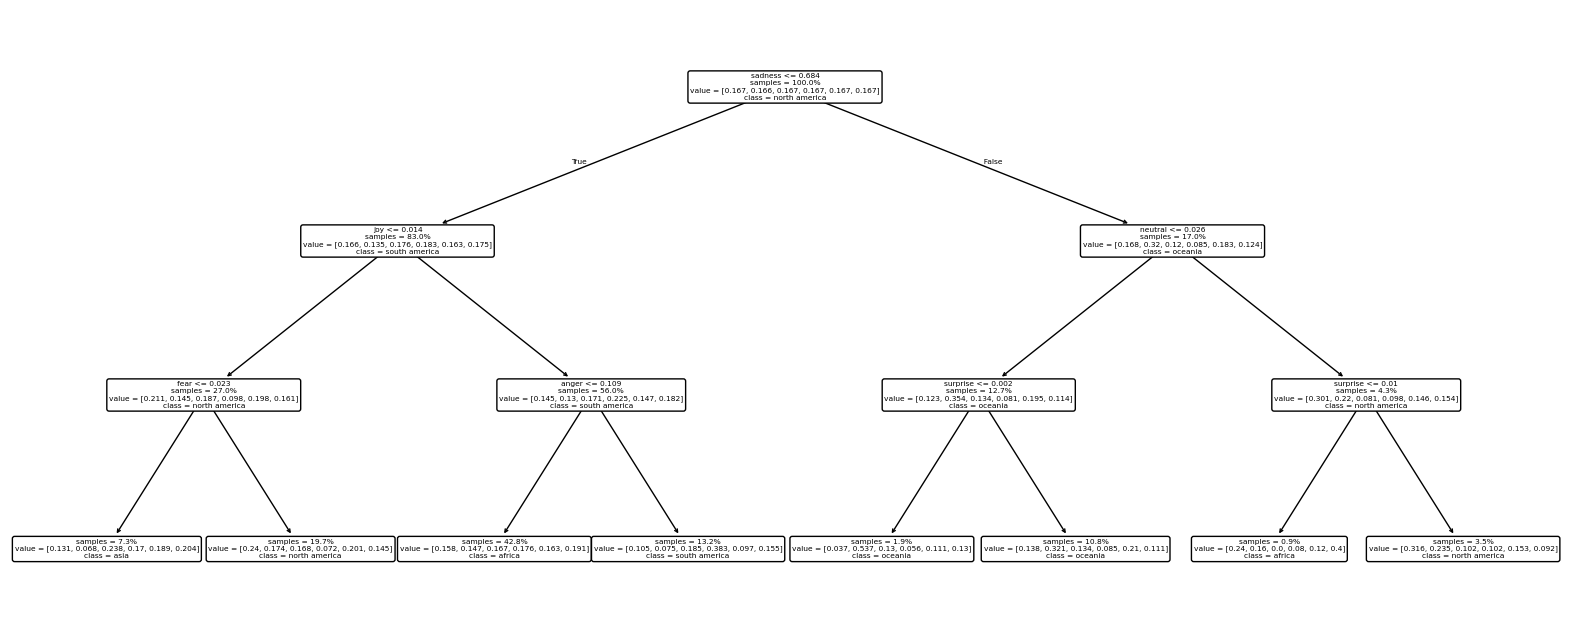

gradient boosting 0.3192090395480226
africa 0.28
asia 0.31
europe 0.37
north america 0.41
oceania 0.29
south america 0.26


In [ ]:
X = emotion_results
Y = df_balanced.original_continent.values
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify = Y)

clf = DecisionTreeClassifier(random_state=0, max_depth=3, min_samples_split = 10, max_features = 3).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('random forest', (y_pred == y_test).mean())

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(clf, feature_names=list_emotions, class_names = y_train, filled=False, impurity = False, proportion = True, rounded = True, ax=ax)
plt.show()

clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=2).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('gradient boosting', (y_pred == y_test).mean())

for ethnicity in np.unique(y_test):
  recall = (y_pred[np.where(y_test == ethnicity)[0]] == ethnicity).mean()
  print(ethnicity, recall.round(2))

The result are clearly higher than 1/6~0.17 (the test dataset is balanced), therefore the emotions are informative.

## Predict the predictions

Here we use the emotion embeddings to predict each model's prediction.

In [ ]:
dic_df_models = {}
for model in df_all_balanced_continent.model.unique():
    df = df_all_balanced_continent[df_all_balanced_continent.model == model]
    df =  df.merge(df_balanced[['original_index', 'emotion_results']], on='original_index', how='left')
    dic_df_models[model] = df

In [ ]:
np.stack(X, axis = 0)

array([[3.64771262e-02, 3.25528003e-04, 6.56670690e-01, ...,
        3.86215770e-03, 4.81064105e-03, 1.35126263e-02],
       [7.03783939e-04, 2.11703693e-04, 6.61992311e-01, ...,
        1.61433045e-03, 8.44298210e-03, 5.38114808e-04],
       [3.38113084e-02, 1.31510955e-03, 2.00219870e-01, ...,
        3.37779857e-02, 3.72927576e-01, 6.24456303e-03],
       ...,
       [2.05589994e-03, 3.46853398e-03, 6.57422021e-02, ...,
        6.59617689e-03, 4.77867909e-02, 1.67710253e-03],
       [3.96520924e-03, 6.49157120e-03, 1.64393510e-03, ...,
        1.75538242e-01, 1.30213559e-01, 4.51385900e-02],
       [1.00974645e-02, 1.41637586e-03, 5.33900857e-01, ...,
        3.80490050e-02, 2.22026501e-02, 4.73587029e-03]])

In [ ]:
n_training = 5

for model in df_all_balanced_continent.model.unique():
    df = dic_df_models[model]
    X = np.stack(df.emotion_results.apply(lambda x : np.array(x)).values, axis = 0)
    Y = df.predicted_continent.values

    mean_acc = 0
    for i in range(n_training):
        X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=i) # , stratify = Y

        clf = GradientBoostingClassifier(n_estimators=100,
                                         learning_rate=0.1,
                                         max_depth=4,
                                         random_state=i)
        clf = clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        mean_acc += (y_pred == y_test).mean()
    mean_acc = mean_acc / n_training
    print(model, mean_acc)

Ground Truth 0.27715582450832066
DeepSeek-7B 0.46045454545454545
DeepSeek-1.5B 0.2775280898876404
Gemma-12B 0.4828006088280061
Llama-8B 0.6935622317596566
Qwen-7B 0.6537537537537538
Ministral-8B 0.7144295302013423
Mistral-24B 0.5365705614567526


We compare the obtained accuracies of the models (mean obtained through the learning process with different seeds) above with the accuracy obtained with a majority class prediction (predicting North America for all except DeepSeek-1.5B) presented below. We see that the XGBoost model does not do better than the majority class -> the emotion embeddings are not informative for the models predictions (with the hypothesis that XGBoost classifier would have been able to use this information otherwise).

In [ ]:
for model in df_all_balanced_continent.model.unique():
    df = dic_df_models[model]
    print(model, df.predicted_continent.value_counts().iloc[0] / len(df))

Ground Truth 0.17418963950318087
DeepSeek-7B 0.5095541401273885
DeepSeek-1.5B 0.35694210230466555
Gemma-12B 0.46725555893999393
Llama-8B 0.7104434907010014
Qwen-7B 0.6759843703035768
Ministral-8B 0.7360644728005373
Mistral-24B 0.5323413300941391


# Visual representation through the emotion embedding

In [ ]:
df_balanced_plutchik = df_balanced.copy()
df_balanced_plutchik['emotion_coordinate'] = df_balanced_plutchik['emotion_results'].apply(lambda x : transform_emotion_list_values_to_cercle_coordinate(x, 'Plutchik'))
df_balanced_plutchik['emotion_coordinate_x'] = df_balanced_plutchik['emotion_coordinate'].apply(lambda x: x[0])
df_balanced_plutchik['emotion_coordinate_y'] = df_balanced_plutchik['emotion_coordinate'].apply(lambda x: x[1])
df_errors = df_all_balanced_continent[(df_all_balanced_continent.prompt_type == 1) | (df_all_balanced_continent.model != 'Ground Truth')].groupby('original_index')[['gender_accuracy', 'continent_accuracy']].mean()
#df_balanced = df_balanced.drop(columns=['gender_accuracy_x', 'continent_accuracy_x', 'gender_accuracy_y', 'continent_accuracy_y'])
df_balanced_plutchik = df_balanced_plutchik.merge(df_errors, on='original_index', how='left')
df_balanced_plutchik['gender_accuracy']    = df_balanced_plutchik['gender_accuracy'].apply(lambda x: x > 0.5)
df_balanced_plutchik['continent_accuracy'] = df_balanced_plutchik['continent_accuracy'].apply(lambda x: x > 0.5)
df_all_balanced_continent_plutchik = df_all_balanced_continent.merge(df_balanced_plutchik[['original_index', 'emotion_coordinate_x', 'emotion_coordinate_y']], on='original_index', how='left')

## General results

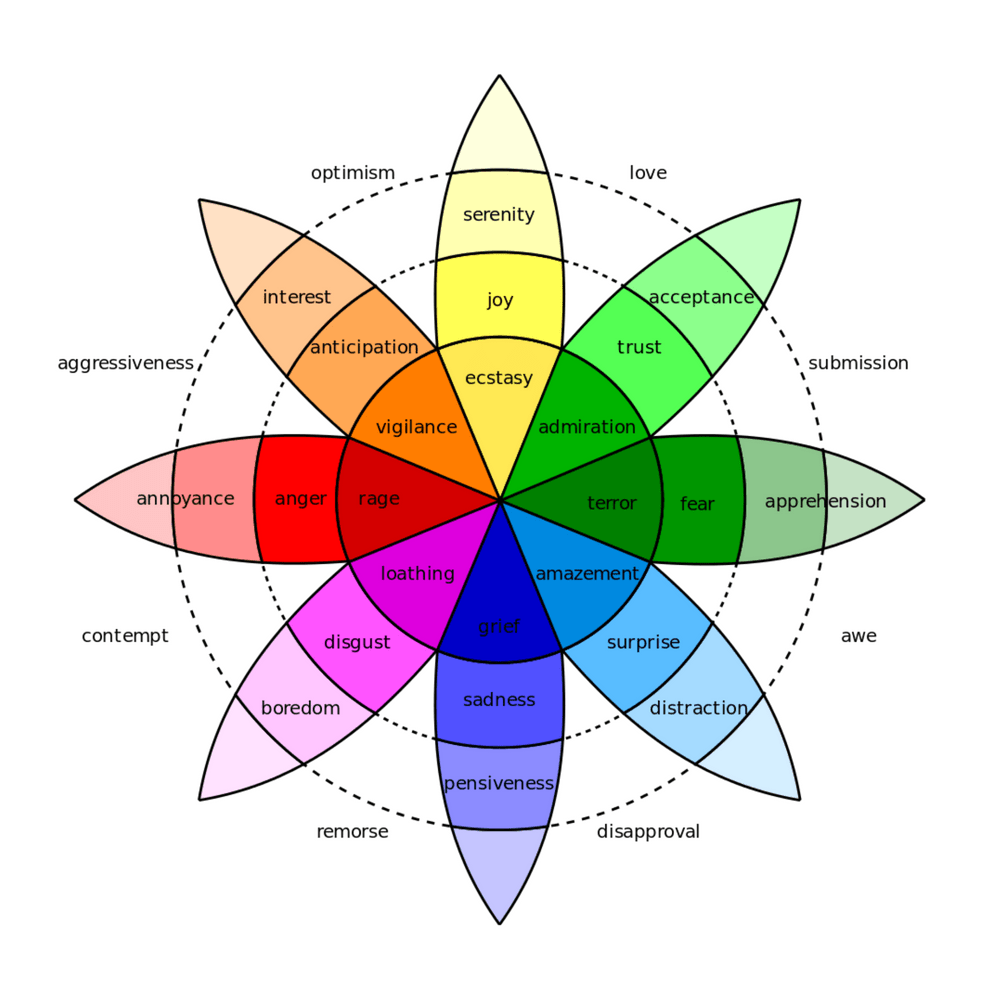

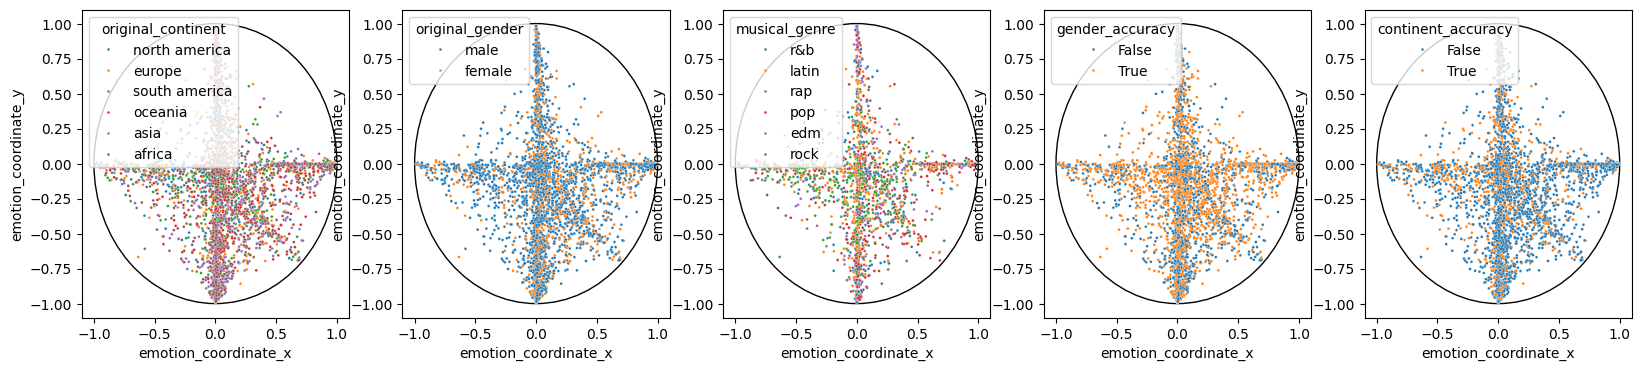

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
df = df_balanced_plutchik.copy()

for count, hue in enumerate(['original_continent', 'original_gender', 'musical_genre', 'gender_accuracy', 'continent_accuracy']):
  plot_cercle_hue(df, axes[count], hue)

plt.show()

## Per model representation

In [ ]:
df_all_balanced_continent_plutchik.model.value_counts()

,count
model,
Llama-8B,3495
Qwen-7B,3327
Ground Truth,3301
Mistral-24B,3293
Gemma-12B,3283
Ministral-8B,2978
DeepSeek-7B,2198
DeepSeek-1.5B,1779


#### Ethnicity analysis

0 0 0
1 0 1
2 0 2
3 0 3
4 1 0
5 1 1
6 1 2


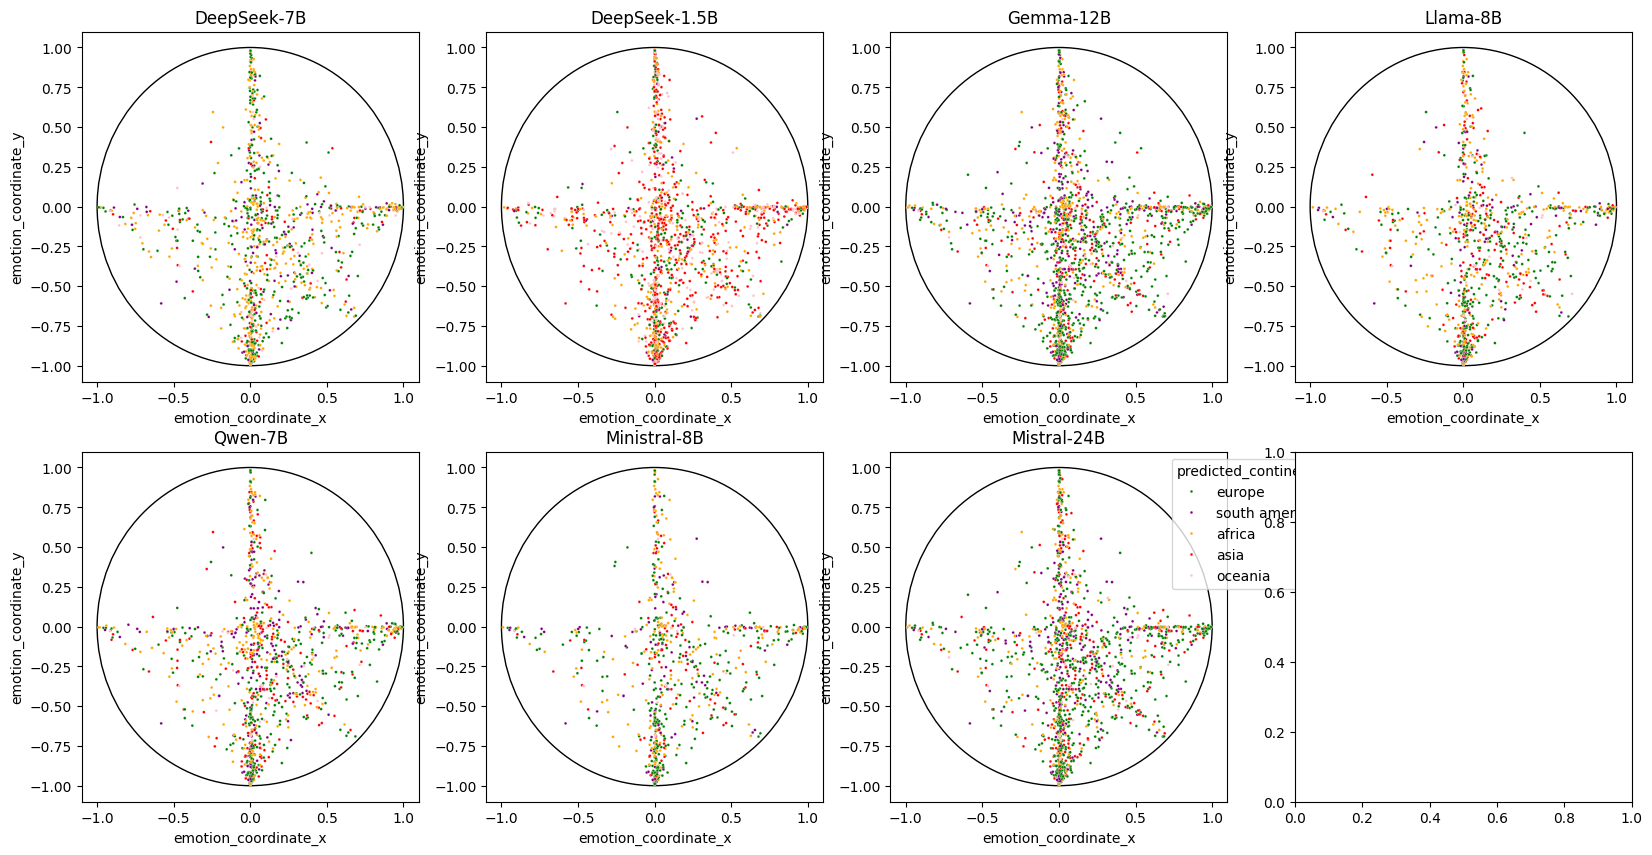

In [ ]:
models = df_all_balanced_continent_plutchik.model.unique()[1:]
n = len(models)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
i = 0
for count, model in enumerate(models):
  i = int((count >= 4 ) * 1.)
  print(count, i, count % 4)
  df = df_all_balanced_continent_plutchik[df_all_balanced_continent_plutchik.model == model].copy()
  df = df[(df.predicted_continent != 'north america') ]
  plot_cercle_hue(df, axes[i, (count % 4)], 'predicted_continent', palette = palette)
  axes[i, count % 4].set_title(model)
  # Get the legend that seaborn already created
  leg =  axes[i, count % 4].get_legend()

  # Move it outside

  if count < 6:
    axes[i, count % 4].legend_.remove()
  else:
    leg.set_bbox_to_anchor((1.3, 1))
    leg.set_loc("upper right")
plt.show()


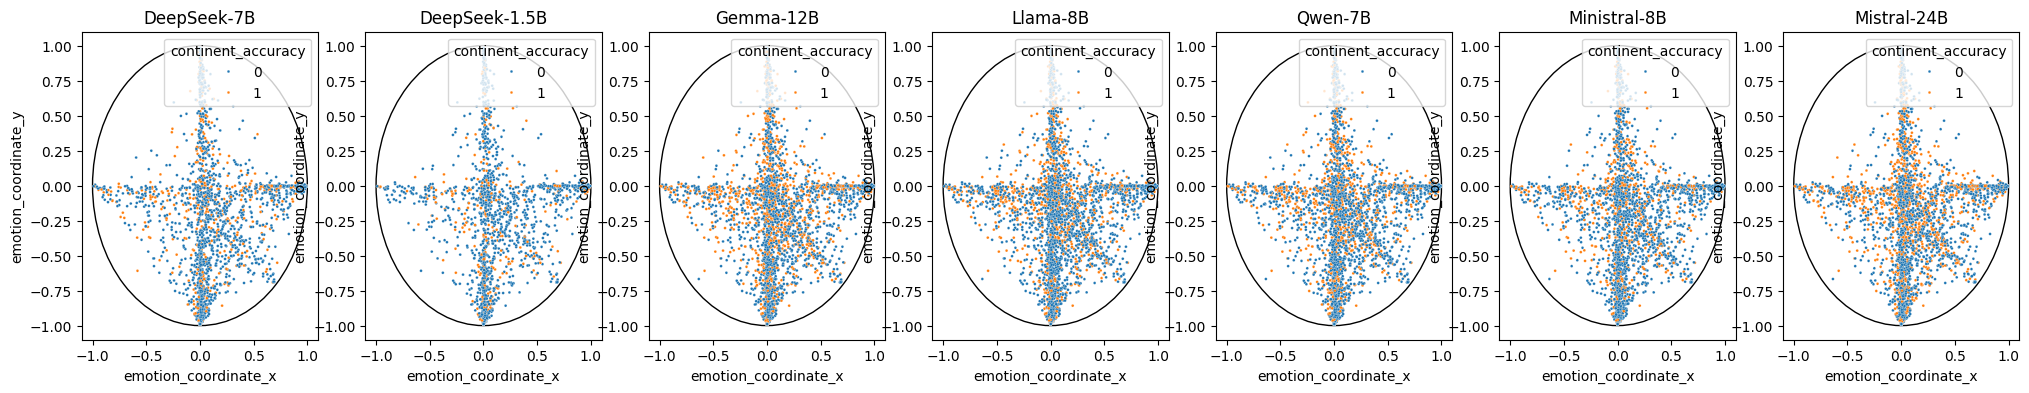

In [ ]:
models = df_all_balanced_continent_plutchik.model.unique()[1:]
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(25, 4))
for count, model in enumerate(models):
    df = df_all_balanced_continent_plutchik[df_all_balanced_continent_plutchik.model == model].copy()
    plot_cercle_hue(df, axes[count], 'continent_accuracy')
    axes[count].set_title(model)
plt.show()


#### Gender analysis

0 0 0
1 0 1
2 0 2
3 0 3
4 1 0
5 1 1
6 1 2


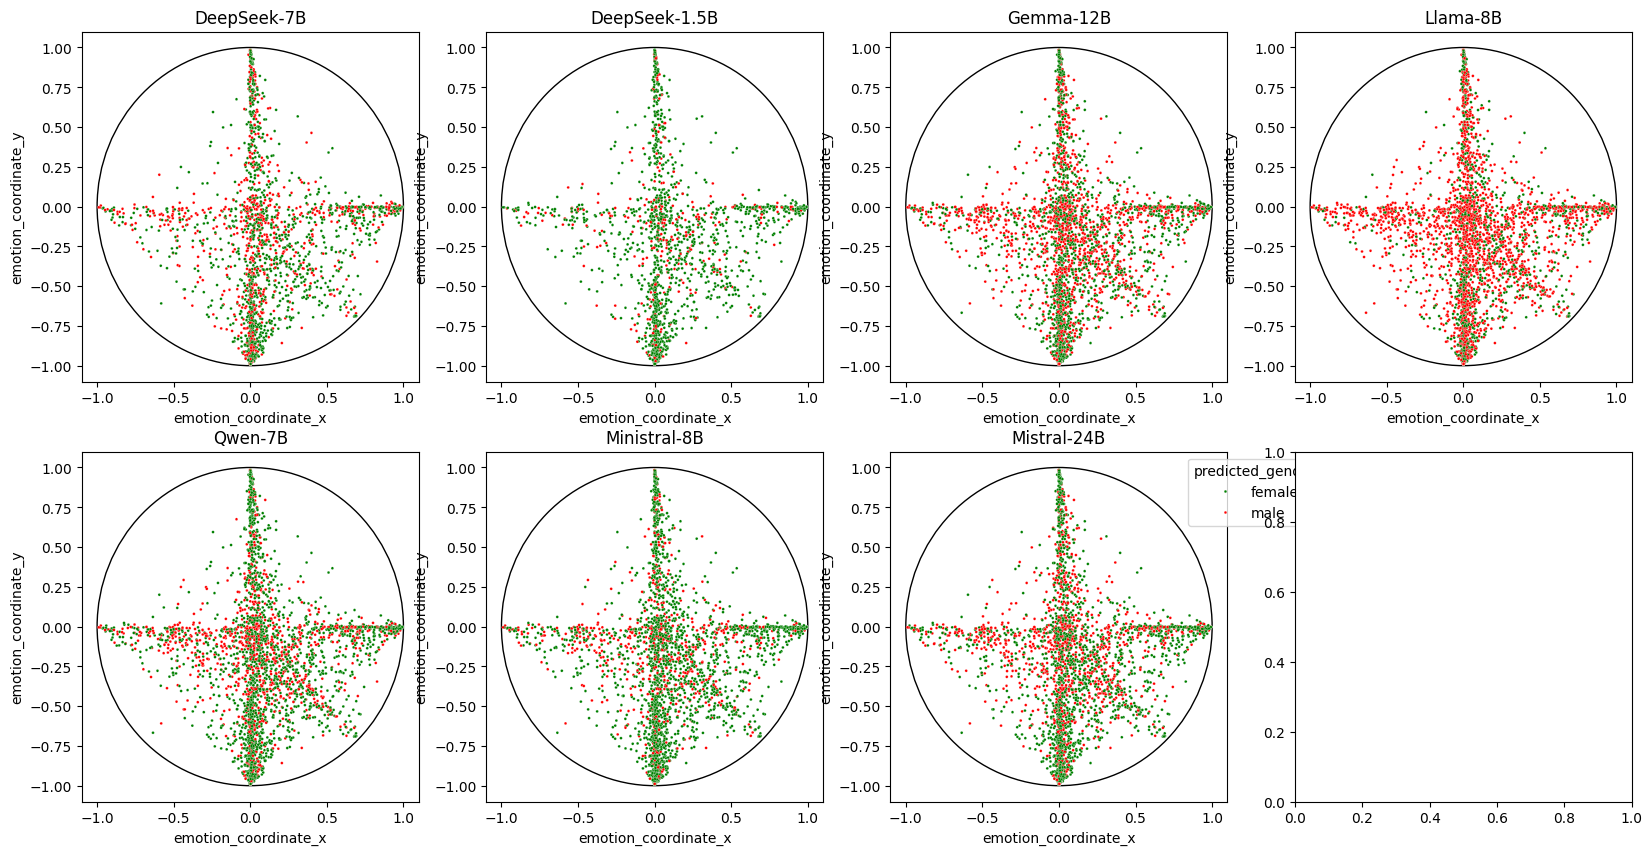

In [ ]:
models = df_all_balanced_continent_plutchik.model.unique()[1:]
n = len(models)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
i = 0
for count, model in enumerate(models):
  i = int((count >= 4 ) * 1.)
  print(count, i, count % 4)
  df = df_all_balanced_continent_plutchik[df_all_balanced_continent_plutchik.model == model].copy()
  plot_cercle_hue(df, axes[i, (count % 4)], 'predicted_gender', palette = palette)
  axes[i, count % 4].set_title(model)
  # Get the legend that seaborn already created
  leg =  axes[i, count % 4].get_legend()

  # Move it outside

  if count < 6:
    axes[i, count % 4].legend_.remove()
  else:
    leg.set_bbox_to_anchor((1.3, 1))
    leg.set_loc("upper right")
plt.show()


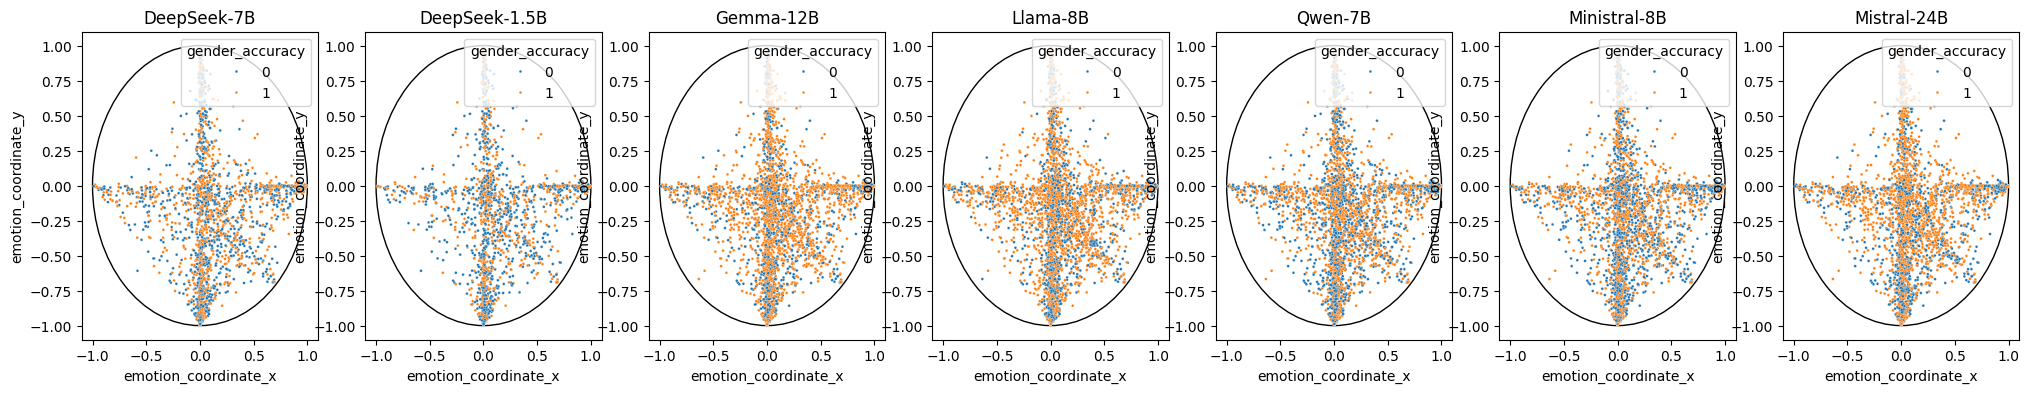

In [ ]:
models = df_all_balanced_continent_plutchik.model.unique()[1:]
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(25, 4))
for count, model in enumerate(models):
    df = df_all_balanced_continent_plutchik[df_all_balanced_continent_plutchik.model == model].copy()
    plot_cercle_hue(df, axes[count], 'gender_accuracy')
    axes[count].set_title(model)
plt.show()


## Russell's model of mood (valence - arousal)


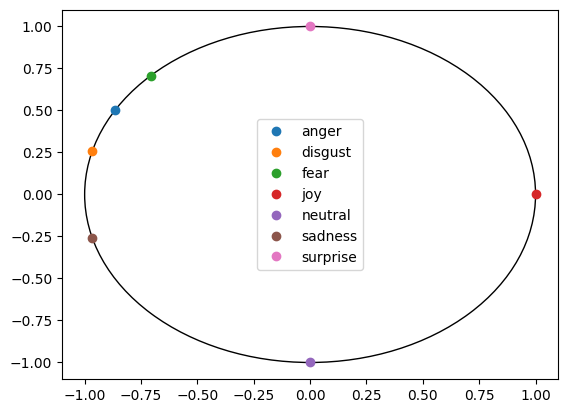

In [ ]:
circle = plt.Circle((0, 0), 1, color='black', fill=False)

fig, ax = plt.subplots()

ax.add_patch(circle)

for emotion in emotion_list:
  x, y = emotion_cordinates[emotion]
  ax.plot(x, y, 'o', label = emotion)
ax.legend()
plt.show()

In [ ]:
df_balanced_russel = df_balanced.copy()
df_balanced_russel['emotion_coordinate'] = df_balanced_russel['emotion_results'].apply(lambda x : transform_emotion_list_values_to_cercle_coordinate(x, 'Russel'))
df_balanced_russel['emotion_coordinate_x'] = df_balanced_russel['emotion_coordinate'].apply(lambda x: x[0])
df_balanced_russel['emotion_coordinate_y'] = df_balanced_russel['emotion_coordinate'].apply(lambda x: x[1])

because the emotions are not informative to the models predictions, we did not investigate further.